In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('C:/Data Science/ecommerce_analysis/data/2019-Oct.csv/2019-Oct.csv')

print(f"\nЗагружено строк: {len(df):,}")
print(f"Период: {df['event_time'].min()} - {df['event_time'].max()}")
print(f"\nТипы событий:")
print(df['event_type'].value_counts())


Загружено строк: 4,102,283
Период: 2019-10-01 00:00:00 UTC - 2019-10-31 23:59:54 UTC

Типы событий:
event_type
view                1862164
cart                1232385
remove_from_cart     762110
purchase             245624
Name: count, dtype: int64



Просмотры: 388,331 пользователей
Добавили в корзину: 133,818 (34.5%)
Совершили покупку: 25,762 (6.6%)

Конверсия корзина -> покупка: 19.3%


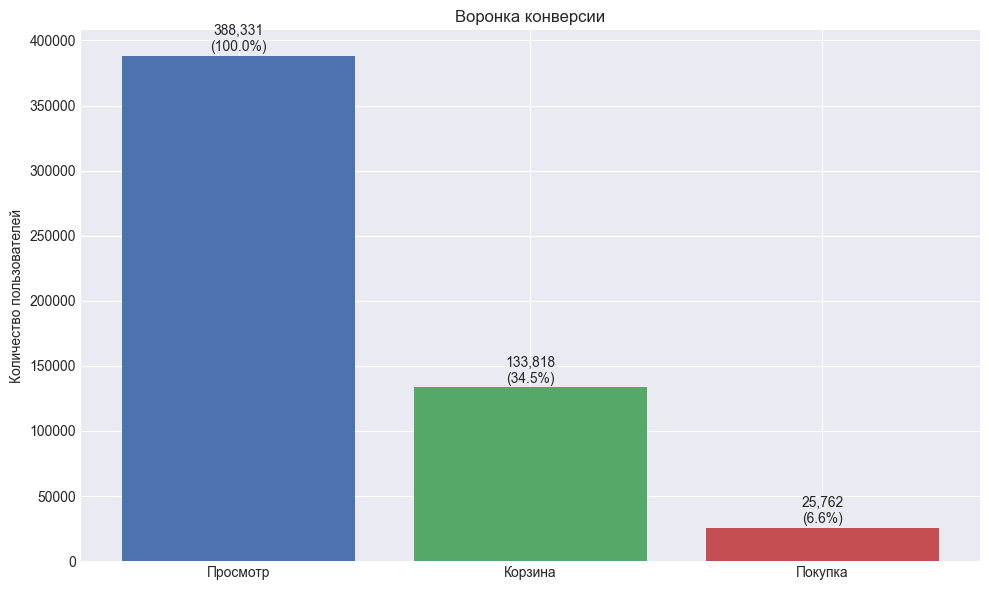

In [16]:
# воронка конверсии

view_users = df[df.event_type == 'view']['user_id'].nunique()
cart_users = df[df.event_type == 'cart']['user_id'].nunique()
purchase_users = df[df.event_type == 'purchase']['user_id'].nunique()

print(f"\nПросмотры: {view_users:,} пользователей")
print(f"Добавили в корзину: {cart_users:,} ({cart_users/view_users*100:.1f}%)")
print(f"Совершили покупку: {purchase_users:,} ({purchase_users/view_users*100:.1f}%)")
print(f"\nКонверсия корзина -> покупка: {purchase_users/cart_users*100:.1f}%")


fig, ax = plt.subplots(1, 1, figsize=(10, 6))

stages = ['Просмотр', 'Корзина', 'Покупка']
counts = [view_users, cart_users, purchase_users]
colors = ['#4C72B0', '#55A868', '#C44E52']

bars = ax.bar(stages, counts, color=colors)
ax.set_ylabel('Количество пользователей')
ax.set_title('Воронка конверсии')

for bar, count in zip(bars, counts):
    percent = count / view_users * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{count:,}\n({percent:.1f}%)', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../images/funnel.png')
plt.show()



Группа 1 (были в выходные):
  Пользователей: 121,222
  Купили: 10,852
  Конверсия: 8.95%

Группа 2 (только в будни):
  Пользователей: 278,442
  Купили: 14,910
  Конверсия: 5.35%

Разница: +3.60 п.п.

p-value: 0.000000

Разница статистически значима (p < 0.05)


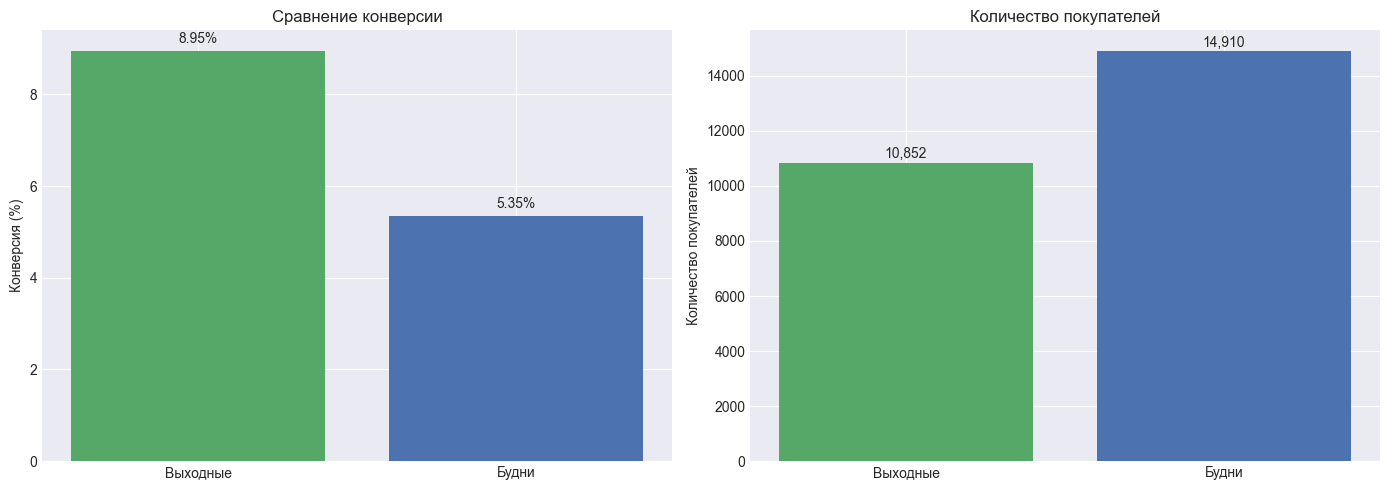

In [17]:
# A/B тест как влияют выходные на покупки

df['event_time'] = pd.to_datetime(df['event_time'])
df['weekday'] = df['event_time'].dt.dayofweek
df['is_weekend'] = df['weekday'].isin([5, 6])  # 5=суббота, 6=воскресенье

# Агрегация по пользователям
user_stats = df.groupby('user_id').agg({
    'event_type': lambda x: 'purchase' in x.values,
    'is_weekend': lambda x: x.any()
}).reset_index()
user_stats.columns = ['user_id', 'made_purchase', 'visited_weekend']

# Группы
group_weekend = user_stats[user_stats.visited_weekend == True]
group_weekday = user_stats[user_stats.visited_weekend == False]

# Конверсия
conv_weekend = group_weekend['made_purchase'].mean() * 100
conv_weekday = group_weekday['made_purchase'].mean() * 100

print(f"\nГруппа 1 (были в выходные):")
print(f"  Пользователей: {len(group_weekend):,}")
print(f"  Купили: {group_weekend['made_purchase'].sum():,}")
print(f"  Конверсия: {conv_weekend:.2f}%")

print(f"\nГруппа 2 (только в будни):")
print(f"  Пользователей: {len(group_weekday):,}")
print(f"  Купили: {group_weekday['made_purchase'].sum():,}")
print(f"  Конверсия: {conv_weekday:.2f}%")

print(f"\nРазница: +{conv_weekend - conv_weekday:.2f} п.п.")

# Статистический тест
table = [
    [group_weekend['made_purchase'].sum(), len(group_weekend) - group_weekend['made_purchase'].sum()],
    [group_weekday['made_purchase'].sum(), len(group_weekday) - group_weekday['made_purchase'].sum()]
]

chi2, p_value, dof, expected = chi2_contingency(table)
print(f"\np-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nРазница статистически значима (p < 0.05)")
else:
    print("\nРазница не является статистически значимой")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

groups = ['Выходные', 'Будни']
conversions = [conv_weekend, conv_weekday]
colors_ab = ['#55A868', '#4C72B0']

bars1 = ax1.bar(groups, conversions, color=colors_ab)
ax1.set_ylabel('Конверсия (%)')
ax1.set_title('Сравнение конверсии')

for bar, conv in zip(bars1, conversions):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{conv:.2f}%', ha='center', va='bottom')

purchases = [group_weekend['made_purchase'].sum(), group_weekday['made_purchase'].sum()]
bars2 = ax2.bar(groups, purchases, color=colors_ab)
ax2.set_ylabel('Количество покупателей')
ax2.set_title('Количество покупателей')

for bar, count in zip(bars2, purchases):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count:,}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../images/ab_test.png')
plt.show()

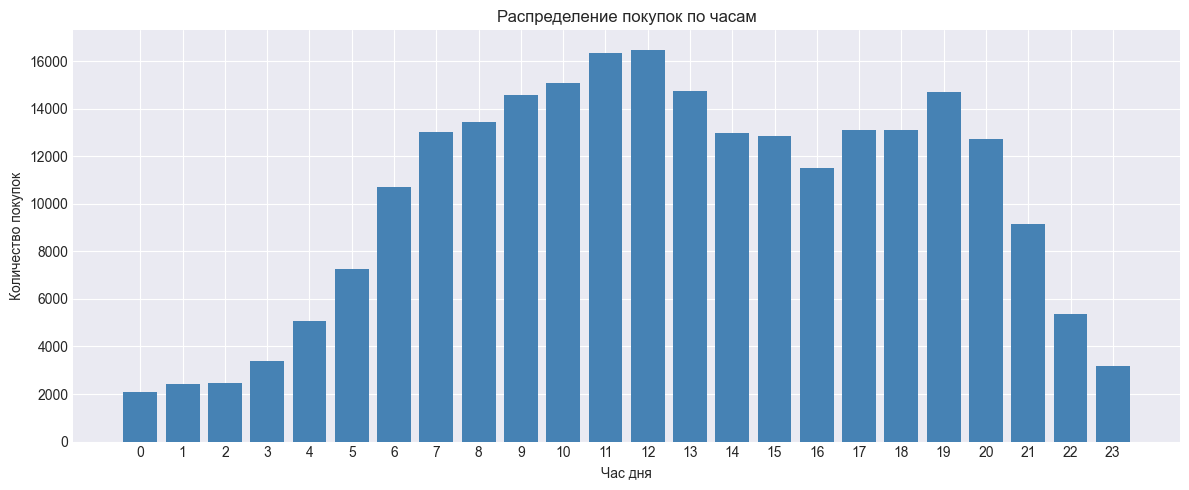


Пик покупок: 12:00


In [18]:
# анализ времени покупок
df_purchases = df[df.event_type == 'purchase'].copy()
df_purchases['hour'] = df_purchases['event_time'].dt.hour
hourly_stats = df_purchases.groupby('hour').size().reset_index(name='purchases')

plt.figure(figsize=(12, 5))
plt.bar(hourly_stats['hour'], hourly_stats['purchases'], color='steelblue')
plt.title('Распределение покупок по часам')
plt.xlabel('Час дня')
plt.ylabel('Количество покупок')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('../images/hourly_purchases.png')
plt.show()

peak_hour = hourly_stats.loc[hourly_stats['purchases'].idxmax(), 'hour']
print(f"\nПик покупок: {peak_hour}:00")